<a href="https://colab.research.google.com/github/ciril7/Applied-Computer-Vision-NLP-IIITK/blob/main/Day%202/HOG_Contour_Convolution_hands_on.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HOG, Contours and Convolution - Separate Image Demonstrations

## HOG Demonstration

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from skimage.feature import hog
from skimage import exposure

Upload image for HOG


Saving NINJA HATTORI.jpg to NINJA HATTORI.jpg


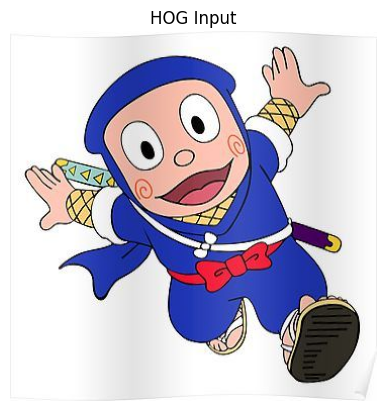

In [8]:
print("Upload image for HOG")
uploaded = files.upload()

hog_file = list(uploaded.keys())[0]

hog_bgr = cv2.imread(hog_file)
hog_rgb = cv2.cvtColor(hog_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(hog_rgb)
plt.axis("off")
plt.title("HOG Input")
plt.show()

hog_gray = cv2.cvtColor(hog_rgb, cv2.COLOR_RGB2GRAY)

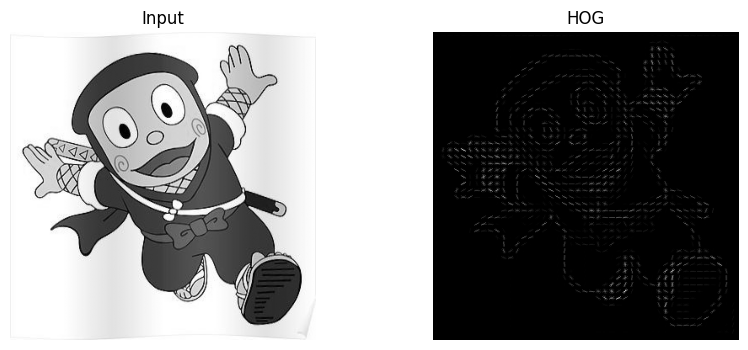

Feature length: 69696


In [9]:
hog_features, hog_image = hog(
    hog_gray,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True,
    feature_vector=True
)

hog_image = exposure.rescale_intensity(hog_image)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(hog_gray,cmap="gray")
plt.title("Input")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(hog_image,cmap="gray")
plt.title("HOG")
plt.axis("off")

plt.show()

print("Feature length:", len(hog_features))

## Contour Demonstration

Upload image for Contours


Saving NINJA HATTORI.jpg to NINJA HATTORI (1).jpg


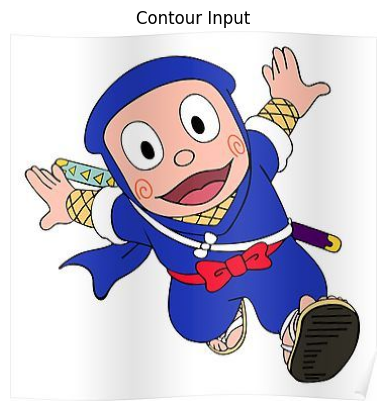

In [10]:
print("Upload image for Contours")
uploaded = files.upload()

contour_file = list(uploaded.keys())[0]

contour_bgr = cv2.imread(contour_file)
contour_rgb = cv2.cvtColor(contour_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(contour_rgb)
plt.axis("off")
plt.title("Contour Input")
plt.show()

contour_gray = cv2.cvtColor(contour_rgb, cv2.COLOR_RGB2GRAY)

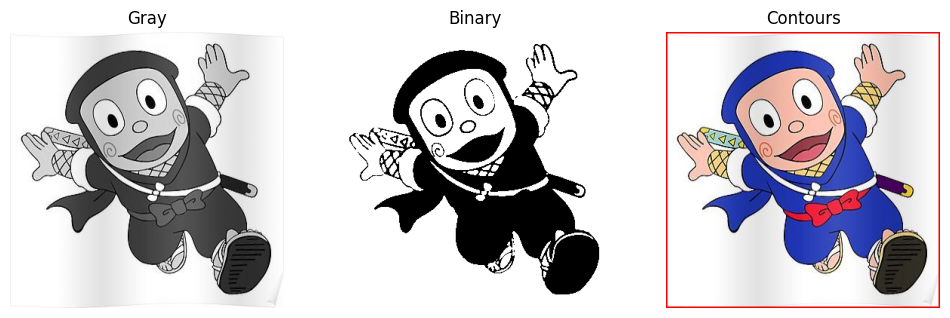

Contours: 1


In [11]:
blur = cv2.GaussianBlur(contour_gray,(5,5),0)

_, binary = cv2.threshold(
    blur,0,255,
    cv2.THRESH_BINARY+cv2.THRESH_OTSU
)

contours, _ = cv2.findContours(
    binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

output = contour_rgb.copy()
cv2.drawContours(output, contours, -1, (255,0,0), 2)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(contour_gray,cmap="gray")
plt.title("Gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(binary,cmap="gray")
plt.title("Binary")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(output)
plt.title("Contours")
plt.axis("off")

plt.show()

print("Contours:", len(contours))

## Convolution Demonstration

Upload image for Convolution


Saving NINJA HATTORI.jpg to NINJA HATTORI (2).jpg


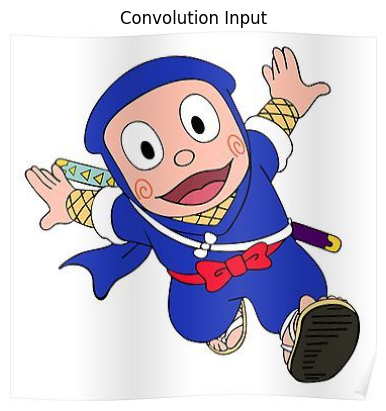

In [12]:
print("Upload image for Convolution")
uploaded = files.upload()

conv_file = list(uploaded.keys())[0]

conv_bgr = cv2.imread(conv_file)
conv_rgb = cv2.cvtColor(conv_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(conv_rgb)
plt.axis("off")
plt.title("Convolution Input")
plt.show()

conv_gray = cv2.cvtColor(conv_rgb, cv2.COLOR_RGB2GRAY)

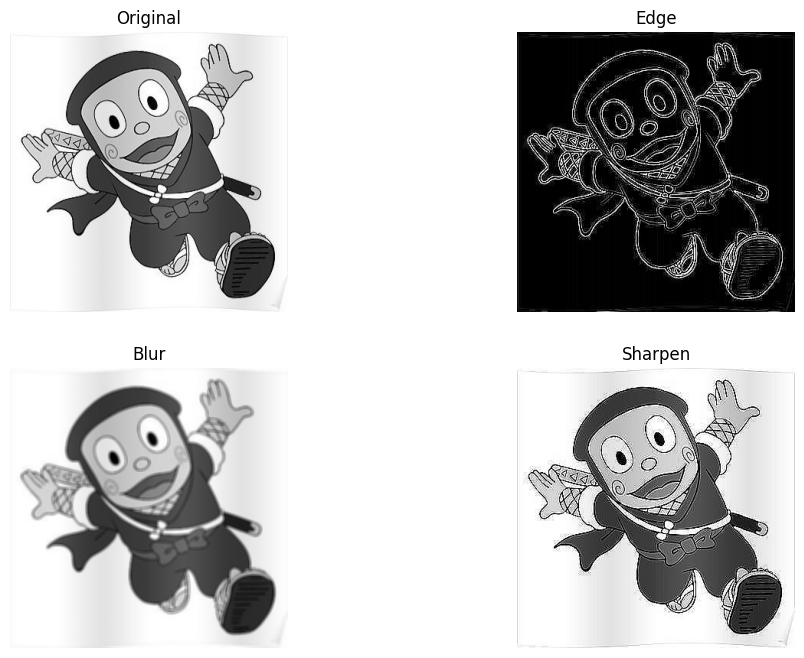

In [13]:
edge_kernel = np.array([
[-1,-1,-1],
[-1, 8,-1],
[-1,-1,-1]
])

blur_kernel = np.ones((5,5))/25

sharpen_kernel = np.array([
[0,-1,0],
[-1,5,-1],
[0,-1,0]
])

edge = cv2.filter2D(conv_gray,-1,edge_kernel)
blur = cv2.filter2D(conv_gray,-1,blur_kernel)
sharp = cv2.filter2D(conv_gray,-1,sharpen_kernel)

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(conv_gray,cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(edge,cmap="gray")
plt.title("Edge")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(blur,cmap="gray")
plt.title("Blur")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(sharp,cmap="gray")
plt.title("Sharpen")
plt.axis("off")

plt.show()